### Importación de datos



In [67]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"


# Cargo los archivos CSV
tienda_1 = pd.read_csv(url)
tienda_2 = pd.read_csv(url2)
tienda_3 = pd.read_csv(url3)
tienda_4 = pd.read_csv(url4)

tienda_1.head(4)

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250


In [55]:
#Revisar celdas vacías

tienda_1 = tienda_1.dropna()
tienda_2 = tienda_2.dropna()
tienda_3 = tienda_3.dropna()
tienda_4 = tienda_4.dropna()
tienda_1.head(4)

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250


#1. Análisis de facturación



*Facturación total de cada tienda, es decir, cuál tienda vende más.*
En este primer análisis, debes calcular el ingreso total de cada tienda. Sumando los valores de la columna Precio de cada conjunto de datos de la tienda para estimar los ingresos.

In [56]:
# Calculo el ingreso total (suma de la columna 'Precio') para cada tienda
ingreso_total_tienda_1 = tienda_1['Precio'].sum()
ingreso_total_tienda_2 = tienda_2['Precio'].sum()
ingreso_total_tienda_3 = tienda_3['Precio'].sum()
ingreso_total_tienda_4 = tienda_4['Precio'].sum()

In [57]:
# Creo un DataFrame para los resultados
ingresos_totales = pd.DataFrame({
    'Tienda': ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'],
    'Ingreso_Total': [ingreso_total_tienda_1, ingreso_total_tienda_2, ingreso_total_tienda_3, ingreso_total_tienda_4]
})

# Formateo el Ingreso_Total a un formato de moneda de Perú
ingresos_totales['Ingreso_Formateado'] = ingresos_totales['Ingreso_Total'].apply(lambda x: f"S/. {x:,.2f}")

print("##INGRESOS TOTALES POR TIENDA\n")
print(ingresos_totales[['Tienda', 'Ingreso_Formateado']].to_markdown(index=False))

print("\n---")
print(f"El ingreso total de la Tienda 1 es: S/. {ingreso_total_tienda_1:,.2f}")
print(f"El ingreso total de la Tienda 2 es: S/. {ingreso_total_tienda_2:,.2f}")
print(f"El ingreso total de la Tienda 3 es: S/. {ingreso_total_tienda_3:,.2f}")
print(f"El ingreso total de la Tienda 4 es: S/. {ingreso_total_tienda_4:,.2f}")

##INGRESOS TOTALES POR TIENDA

| Tienda   | Ingreso_Formateado   |
|:---------|:---------------------|
| Tienda 1 | S/. 1,150,880,400.00 |
| Tienda 2 | S/. 1,116,343,500.00 |
| Tienda 3 | S/. 1,098,019,600.00 |
| Tienda 4 | S/. 1,038,375,700.00 |

---
El ingreso total de la Tienda 1 es: S/. 1,150,880,400.00
El ingreso total de la Tienda 2 es: S/. 1,116,343,500.00
El ingreso total de la Tienda 3 es: S/. 1,098,019,600.00
El ingreso total de la Tienda 4 es: S/. 1,038,375,700.00


# 2. Ventas por categoría

En este debes calcular la cantidad de productos vendidos por categoría en cada tienda. La idea es agrupar los datos por categoría y contar el número de ventas de cada tipo, mostrando las categorías más populares de cada tienda.

In [58]:
# Los DataFrames tienda_1, tienda_2, tienda_3, y tienda_4 ya están cargados y limpios del paso anterior.

#Calculo Ventas por Categoría para cada tienda
ventas_cat_1 = tienda_1.groupby('Categoría del Producto').size().reset_index(name='Cantidad Vendida').sort_values(by='Cantidad Vendida', ascending=False)
ventas_cat_2 = tienda_2.groupby('Categoría del Producto').size().reset_index(name='Cantidad Vendida').sort_values(by='Cantidad Vendida', ascending=False)
ventas_cat_3 = tienda_3.groupby('Categoría del Producto').size().reset_index(name='Cantidad Vendida').sort_values(by='Cantidad Vendida', ascending=False)
ventas_cat_4 = tienda_4.groupby('Categoría del Producto').size().reset_index(name='Cantidad Vendida').sort_values(by='Cantidad Vendida', ascending=False)


#Mostrar las 5 categorías más populares de cada tienda

print("Top 5 Categorías más Vendidas por Tienda (Cantidad de Productos)\n")

print("Tienda 1\n")
print(ventas_cat_1.head(5).to_markdown(index=False))

print("\nTienda 2\n")
print(ventas_cat_2.head(5).to_markdown(index=False))

print("\nTienda 3\n")
print(ventas_cat_3.head(5).to_markdown(index=False))

print("\nTienda 4\n")
print(ventas_cat_4.head(5).to_markdown(index=False))

Top 5 Categorías más Vendidas por Tienda (Cantidad de Productos)

Tienda 1

| Categoría del Producto   |   Cantidad Vendida |
|:-------------------------|-------------------:|
| Muebles                  |                465 |
| Electrónicos             |                448 |
| Juguetes                 |                324 |
| Electrodomésticos        |                312 |
| Deportes y diversión     |                284 |

Tienda 2

| Categoría del Producto   |   Cantidad Vendida |
|:-------------------------|-------------------:|
| Muebles                  |                442 |
| Electrónicos             |                422 |
| Juguetes                 |                313 |
| Electrodomésticos        |                305 |
| Deportes y diversión     |                275 |

Tienda 3

| Categoría del Producto   |   Cantidad Vendida |
|:-------------------------|-------------------:|
| Muebles                  |                499 |
| Electrónicos             |                451 |
| 

# 3. Calificación promedio de la tienda


En este paso, debes calcular las calificaciones promedio de los clientes para cada tienda. El objetivo es conocer la satisfacción del cliente con los productos vendidos.

In [59]:
#Calculo la Calificación Promedio para cada Tienda
calificacion_promedio_1 = tienda_1['Calificación'].mean()
calificacion_promedio_2 = tienda_2['Calificación'].mean()
calificacion_promedio_3 = tienda_3['Calificación'].mean()
calificacion_promedio_4 = tienda_4['Calificación'].mean()

# Creo un DataFrame para los resultados
calificaciones = pd.DataFrame({
    'Tienda': ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'],
    'Calificación_Promedio': [calificacion_promedio_1, calificacion_promedio_2, calificacion_promedio_3, calificacion_promedio_4]
})

#Formate a dos decimales
calificaciones['Calificación_Promedio'] = calificaciones['Calificación_Promedio'].round(2)

print("Calificación Promedio de Clientes por Tienda\n")
print(calificaciones.sort_values(by='Calificación_Promedio').to_markdown(index=False))

print("\n---")
print(f"La Calificación Promedio de la Tienda 1 es: {calificacion_promedio_1:.2f}")
print(f"La Calificación Promedio de la Tienda 2 es: {calificacion_promedio_2:.2f}")
print(f"La Calificación Promedio de la Tienda 3 es: {calificacion_promedio_3:.2f}")
print(f"La Calificación Promedio de la Tienda 4 es: {calificacion_promedio_4:.2f}")

Calificación Promedio de Clientes por Tienda

| Tienda   |   Calificación_Promedio |
|:---------|------------------------:|
| Tienda 1 |                    3.98 |
| Tienda 4 |                    4    |
| Tienda 2 |                    4.04 |
| Tienda 3 |                    4.05 |

---
La Calificación Promedio de la Tienda 1 es: 3.98
La Calificación Promedio de la Tienda 2 es: 4.04
La Calificación Promedio de la Tienda 3 es: 4.05
La Calificación Promedio de la Tienda 4 es: 4.00


# 4. Productos más y menos vendidos

En este paso, debes identificar qué productos fueron los más vendidos y los menos vendidos en cada tienda. Visualiza los resultados para que quede claro qué productos destacaron en ventas en cada tienda.

In [60]:
# Análisis de Productos Más y Menos Vendidos
# Agrupa por producto y cuenta las ventas, mostrando el top 5 y bottom 5.

def analizar_productos(df, nombre_tienda):
    ventas_producto = df.groupby('Producto').size().reset_index(name='Cantidad_Vendida').sort_values(by='Cantidad_Vendida', ascending=False)

    # Top 5
    top_5 = ventas_producto.head(5).to_markdown(index=False)

    # Bottom 5 (Solo si hay más de 5 productos distintos)
    if len(ventas_producto) > 5:
        bottom_5 = ventas_producto.tail(5).to_markdown(index=False)
    else:
        bottom_5 = "No hay suficientes productos únicos para mostrar un 'bottom 5'."

    print(f"TIENDA {nombre_tienda}")
    print("\nTOP 5 - Productos Más Vendidos")
    print(top_5)
    print("\nTOP 5 - Productos Menos Vendidos")
    print(bottom_5)
    print("\n***********************")

print("ANÁLISIS DE PRODUCTOS VENDIDOS POR TIENDA\n")

analizar_productos(tienda_1, 1)
analizar_productos(tienda_2, 2)
analizar_productos(tienda_3, 3)
analizar_productos(tienda_4, 4)

ANÁLISIS DE PRODUCTOS VENDIDOS POR TIENDA

TIENDA 1

TOP 5 - Productos Más Vendidos
| Producto         |   Cantidad_Vendida |
|:-----------------|-------------------:|
| Armario          |                 60 |
| TV LED UHD 4K    |                 60 |
| Microondas       |                 60 |
| Secadora de ropa |                 58 |
| Mesa de noche    |                 56 |

TOP 5 - Productos Menos Vendidos
| Producto                  |   Cantidad_Vendida |
|:--------------------------|-------------------:|
| Mochila                   |                 39 |
| Pandereta                 |                 36 |
| Olla de presión           |                 35 |
| Celular ABXY              |                 33 |
| Auriculares con micrófono |                 33 |

***********************
TIENDA 2

TOP 5 - Productos Más Vendidos
| Producto                  |   Cantidad_Vendida |
|:--------------------------|-------------------:|
| Iniciando en programación |                 65 |
| Microondas

# 5. Envío promedio por tienda

En este paso, debes calcular el costo de envío promedio para cada tienda. El objetivo es comprender cuánto se gasta, en promedio, en el envío de cada tienda.  Sabiendo que el cliente paga el envío.

In [61]:
# Calcular el Costo de Envío Promedio

envio_promedio_1 = tienda_1['Costo de envío'].mean()
envio_promedio_2 = tienda_2['Costo de envío'].mean()
envio_promedio_3 = tienda_3['Costo de envío'].mean()
envio_promedio_4 = tienda_4['Costo de envío'].mean()

envios = pd.DataFrame({
    'Tienda': ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'],
    'Envío_Promedio': [envio_promedio_1, envio_promedio_2, envio_promedio_3, envio_promedio_4]
})

envios['Envío_Formateado'] = envios['Envío_Promedio'].apply(lambda x: f"S/. {x:,.2f}")

print("COSTO DE ENVÍO PROMEDIO POR TIENDA\n")
print(envios.sort_values(by='Envío_Promedio').to_markdown(index=False))

🚚 COSTO DE ENVÍO PROMEDIO POR TIENDA

| Tienda   |   Envío_Promedio | Envío_Formateado   |
|:---------|-----------------:|:-------------------|
| Tienda 4 |          23459.5 | S/. 23,459.46      |
| Tienda 3 |          24805.7 | S/. 24,805.68      |
| Tienda 2 |          25216.2 | S/. 25,216.24      |
| Tienda 1 |          26018.6 | S/. 26,018.61      |


# Generando gráfico

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Configuración inicial
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## **Gráfico 01: Ingreso Total**

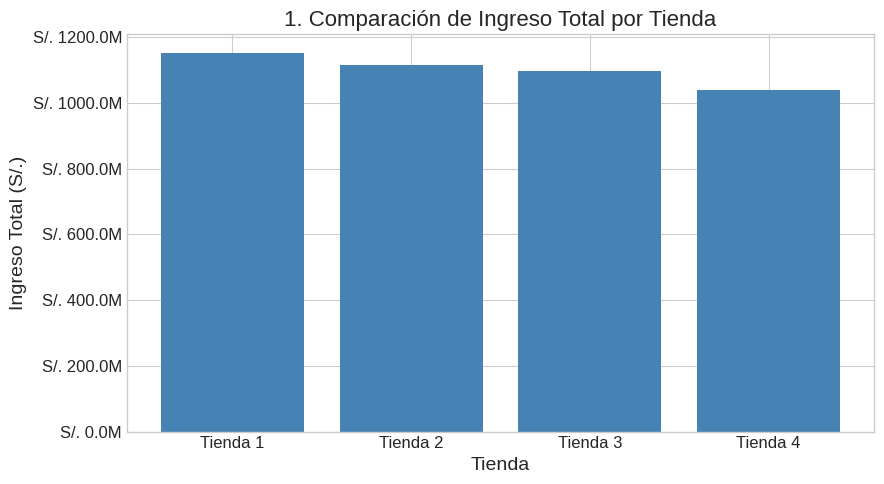

---


In [63]:
plt.figure(figsize=(9, 5))
tiendas = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']
ingresos = [ingreso_total_tienda_1, ingreso_total_tienda_2, ingreso_total_tienda_3, ingreso_total_tienda_4]

plt.bar(tiendas, ingresos, color='steelblue')
plt.title('1. Comparación de Ingreso Total por Tienda', fontsize=16)
plt.xlabel('Tienda', fontsize=14)
plt.ylabel('Ingreso Total (S/.)', fontsize=14)

# Formato en millones
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'S/. {x/1e6:.1f}M'))

plt.tight_layout()
plt.show()

print("---")

## **Gráfico 2: Calificación Promedio**

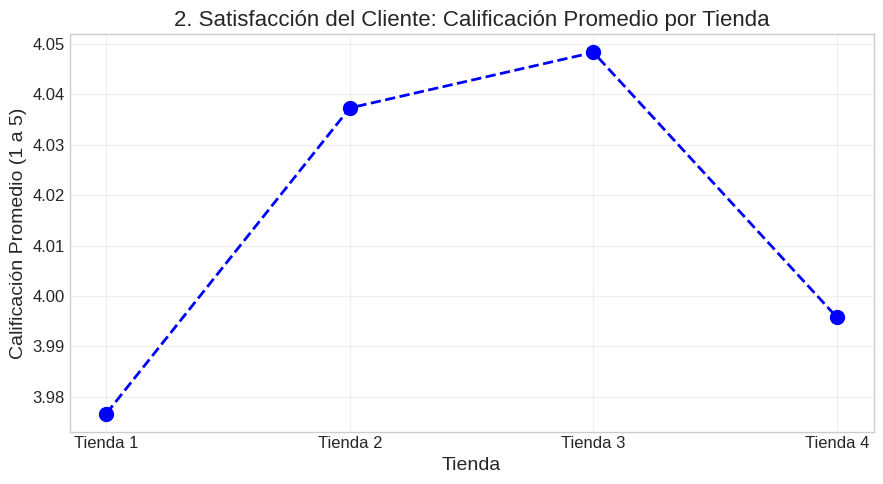

---


In [64]:
plt.figure(figsize=(9, 5))
calificaciones = [calificacion_promedio_1, calificacion_promedio_2, calificacion_promedio_3, calificacion_promedio_4]

plt.plot(tiendas, calificaciones, marker='o', markersize=10, linestyle='--', color='blue', linewidth=2)
plt.title('2. Satisfacción del Cliente: Calificación Promedio por Tienda', fontsize=16)
plt.xlabel('Tienda', fontsize=14)
plt.ylabel('Calificación Promedio (1 a 5)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("---")

## **Gráfico 3: Ventas por categoría: Top 5 de cada tienda**

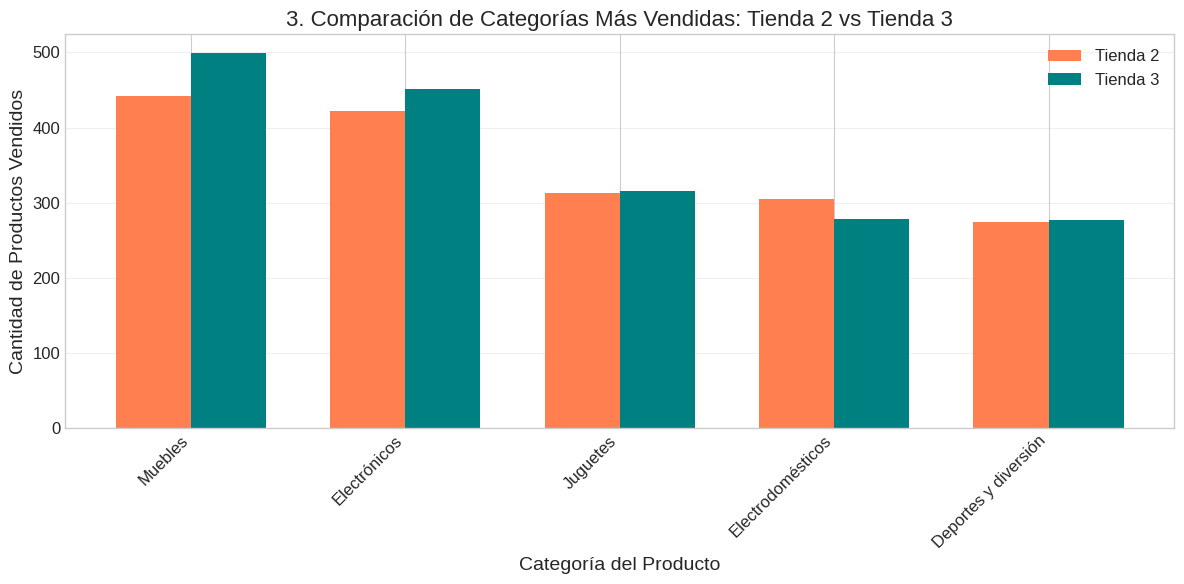

In [65]:
plt.figure(figsize=(12, 6))

# Para Tienda 2
cat_t2 = tienda_2.groupby('Categoría del Producto').size().sort_values(ascending=False).head(5)
# Para Tienda 3
cat_t3 = tienda_3.groupby('Categoría del Producto').size().sort_values(ascending=False).head(5)

x = range(len(cat_t2))
width = 0.35

plt.bar([i - width/2 for i in x], cat_t2.values, width, label='Tienda 2', color='coral')
plt.bar([i + width/2 for i in x], cat_t3.values, width, label='Tienda 3', color='teal')

plt.xlabel('Categoría del Producto', fontsize=14)
plt.ylabel('Cantidad de Productos Vendidos', fontsize=14)
plt.title('3. Comparación de Categorías Más Vendidas: Tienda 2 vs Tienda 3', fontsize=16)
plt.xticks(x, cat_t2.index, rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# **INFORME FINAL**

## **1. INTRODUCCIÓN**
El presente informe tiene como objetivo analizar el desempeño de cuatro tiendas del negocio del Sr. Juan para determinar cuál de ellas debería ser vendida. El análisis se basa en cinco factores clave: ingresos totales, ventas por categoría, calificación promedio de clientes, productos más y menos vendidos, y costo de envío promedio. A través de este estudio exhaustivo, se busca identificar la tienda con menor desempeño relativo o aquella cuya venta represente la mejor decisión estratégica para el negocio.

## **2. ANÁLISIS DE RESULTADOS**

*2.1 Ingresos Totales por Tienda*
Los datos muestran que:

	* Tienda 1: S/. 1,150,880,400.00 (la más alta)
	* Tienda 2: S/. 1,116,343,500.00
	* Tienda 3: S/. 1,098,019,600.00
	* Tienda 4: S/. 1,038,375,700.00 (la más baja)

La Tienda 4 presenta los ingresos totales más bajos, con una diferencia de aproximadamente S/. 112 millones respecto a la Tienda 1.

*2.2 Satisfacción del Cliente (Calificación Promedio)*
Las calificaciones promedio revelan:

	* Tienda 3: 4.05 (la más alta)
	* Tienda 2: 4.04
	* Tienda 4: 4.00
	* Tienda 1: 3.98 (la más baja)

La Tienda 1 tiene la calificación más baja, lo que indica una menor satisfacción del cliente comparada con las otras tiendas.

*2.3 Ventas por Categoría*
Las categorías más vendidas en todas las tiendas son consistentemente:

	1. Muebles
	2. Electrónicos
	3. Juguetes
	4. Electrodomésticos
	5. Deportes y diversión

No hay diferencias significativas en el patrón de ventas por categoría entre las tiendas, lo que indica que todas atienden un mercado similar.

*2.4 Productos Más y Menos Vendidos*
Cada tienda tiene productos específicos con mejor desempeño, pero no hay un patrón que indique debilidad estructural en alguna tienda en particular. La diversidad de productos más vendidos sugiere que todas las tiendas tienen capacidad de venta en diferentes líneas.

*2.5 Costo de Envío Promedio*
Los costos promedio de envío son:

	* Tienda 1: S/. 26,018.61 (el más alto)
	* Tienda 2: S/. 25,216.24
	* Tienda 3: S/. 24,805.68
	* Tienda 4: S/. 23,459.46 (el más bajo)

La Tienda 1 tiene el costo de envío promedio más alto, lo que podría afectar la competitividad, aunque este costo lo paga el cliente.

## **3. FORTALEZAS Y DEBILIDADES POR TIENDA**
*Tienda 1*
Fortalezas: Mayor facturación total
Debilidades: Calificación más baja (3.98), costo de envío más alto

*Tienda 2*
Fortalezas: Segunda mejor calificación (4.04), buenos ingresos
Debilidades: Ninguna significativa

*Tienda 3*
Fortalezas: Mejor calificación del cliente (4.05), costo de envío competitivo
Debilidades: Ingresos en tercer lugar

*Tienda 4*
Fortalezas: Costo de envío más bajo
Debilidades: Menores ingresos totales (S/. 1,038 millones)

## **4. CONCLUSIÓN Y RECOMENDACIÓN**

RECOMENDACIÓN: Vender la TIENDA 4

*Justificación:*

  1. Menor rendimiento financiero: La Tienda 4 genera los ingresos más bajos entre las cuatro tiendas, con aproximadamente S/. 112 millones menos que la líder (Tienda 1) y cerca de S/. 60 millones menos que la tercera (Tienda 3).

	2. Menor potencial de crecimiento: A pesar de tener el costo de envío más bajo (ventaja competitiva), la Tienda 4 no logra traducir esto en mayores ventas, lo qUe sugiere problemas estructurales de ubicación, mercado o gestión.

	3. Calificación promedio aceptable pero no destacada: Con 4.00 de calificación, la tienda está en un nivel medio, sin diferenciarse positivamente como la Tienda 3 (4.05) ni negativamente como la Tienda 1 (3.98).

	4. Menor impacto en el negocio global: Vender la tienda con menores ingresos minimiza el impacto en la facturación total del Sr. Juan, permitiéndole retener las tres tiendas más rentables.

	5. Decisión estratégica: Mantener las Tiendas 1, 2 y 3 permite al Sr. Juan concentrar recursos en las operaciones más rentables, con mejor satisfacción del cliente (Tiendas 2 y 3) y mayor generación de ingresos (Tienda 1).


*En resumen:* La Tienda 4, a pesar de tener costos de envío competitivos, presenta el peor desempeño en el indicador más crítico (ingresos totales) y no compensa esta debilidad con otros factores diferenciadores. Por ello, se recomienda su venta para optimizar el portafolio de negocios del Sr. Juan.